# Optimización del calendario de talleres mediante Gurobi
# Trabajo Fin de Máster

## Business Analytics aplicado a FOOD&FUN: análisis, predicción y optimización para la toma de decisiones

**Autora:** Francisca Concha

**Máster en Business Analytics e Inteligencia de Negocio**

**Universidad Católica de Valencia**

**Curso académico 2025–2026**


# Optimización del calendario de talleres mediante Gurobi

Una vez estimada la demanda futura de la empresa y analizados los factores que influyen en la ocupación de los cursos, el siguiente paso consiste en determinar qué talleres deben programarse para maximizar la asistencia esperada.

Para ello se desarrollará un modelo de optimización basado en programación matemática utilizando Gurobi. El objetivo será seleccionar la combinación de talleres que permita aprovechar al máximo la demanda prevista, respetando las restricciones operativas de la empresa.

In [2]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [3]:
import gurobipy as gp

print(gp.gurobi.version())

(13, 0, 2)


In [4]:
import gurobipy as gp

modelo = gp.Model("Prueba")

Set parameter Username
Set parameter LicenseID to value 2800922


# 1. Objetivo del proyecto 
Optimización del calendario de talleres mediante Gurobi

El presente notebook tiene como objetivo desarrollar un modelo de optimización que permita diseñar un calendario de talleres alineado con la demanda prevista de la empresa Food&Fun.

En los notebooks anteriores se desarrollaron modelos de predicción de demanda y análisis de ocupación de talleres. Los resultados obtenidos permitieron identificar patrones de comportamiento de los clientes, así como los talleres con mayor capacidad de atracción.

A partir de dicha información, se utilizará programación matemática mediante Gurobi para determinar la combinación óptima de talleres que maximice la asistencia esperada respetando las restricciones operativas del negocio.

# 2. Importación de librerías

In [6]:
# Manipulación de datos

import pandas as pd
import numpy as np

# Visualización

import matplotlib.pyplot as plt

# Optimización

import gurobipy as gp
from gurobipy import GRB

# 3. Carga de datos

In [7]:
# Cargar datos históricos

df = pd.read_excel(
    "Compras_2526_F&F.xlsx"
)

df.head()

,Fecha de Compra,Número de Pedido,Taller,Fecha Taller,Cantidad de Plazas,TARJETAS REGALO,Importe Total,IMPORTE DEVOLUCIÓN,Método de Pago
0,2024-11-18,43856526,Tarjeta Regalo,NaN,0,1.0,150.0,NaN,Visa
1,2025-01-01,43861545,Kimchi,2025-03-24 00:00:00,2,NaN,180.0,NaN,Bizum
2,2025-01-01,43861547,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Visa
3,2025-01-01,43861597,Tarjeta Regalo,NaN,0,0.0,0.0,NaN,Devolución
4,2025-01-01,43861549,Ramen,2025-03-28 00:00:00,2,NaN,162.0,NaN,Visa


# 4. Preparación de los datos


Con el fin de construir el modelo de optimización, se calculará la ocupación media histórica de cada taller. Esta información se utilizará como estimación de la demanda esperada para cada tipo de curso.

In [8]:
# Convertir fecha del taller

df["Fecha Taller"] = pd.to_datetime(
    df["Fecha Taller"],
    errors="coerce"
)

In [9]:
# Eliminar registros sin fecha de taller

df_talleres = df.dropna(
    subset=["Fecha Taller"]
).copy()

In [10]:
# Ocupación por taller y fecha

ocupacion_talleres = (
    df_talleres
    .groupby(
        ["Taller", "Fecha Taller"]
    )["Cantidad de Plazas"]
    .sum()
    .reset_index(name="Asistentes")
)

ocupacion_talleres.head()

,Taller,Fecha Taller,Asistentes
0,Clasicos Valencianos,2026-03-29,0
1,Clasicos Valencianos,2026-06-13,3
2,Cocas Miquel Ruiz,2025-07-12,25
3,Croquetas,2026-04-18,3
4,Croquetas,2026-05-30,3


# 5. Obtención de la ocupación media por taller

In [11]:
# Calcular ocupación media histórica

ocupacion_media = (
    ocupacion_talleres
    .groupby("Taller")["Asistentes"]
    .mean()
    .reset_index()
)

ocupacion_media

,Taller,Asistentes
0,Clasicos Valencianos,1.500000
1,Cocas Miquel Ruiz,25.000000
2,Croquetas,3.000000
3,Curso Cocina Mexicana,6.333333
4,Curso de Arroces,13.083333
5,Esperando selección de curso,1.666667
6,Kimchi,17.333333
7,NOBLE,4.000000
8,Paella Lovers,8.821429
9,Ramen,13.250000


In [12]:
# Ordenar talleres por ocupación

ocupacion_media = (
    ocupacion_media
    .sort_values(
        by="Asistentes",
        ascending=False
    )
)

ocupacion_media

,Taller,Asistentes
1,Cocas Miquel Ruiz,25.000000
10,Raíces,20.666667
6,Kimchi,17.333333
9,Ramen,13.250000
4,Curso de Arroces,13.083333
12,Sushi,11.578947
14,Taller de Pasta Fresca,10.714286
8,Paella Lovers,8.821429
16,Tapas Españolas,8.111111
15,Taller de Principiantes,8.000000


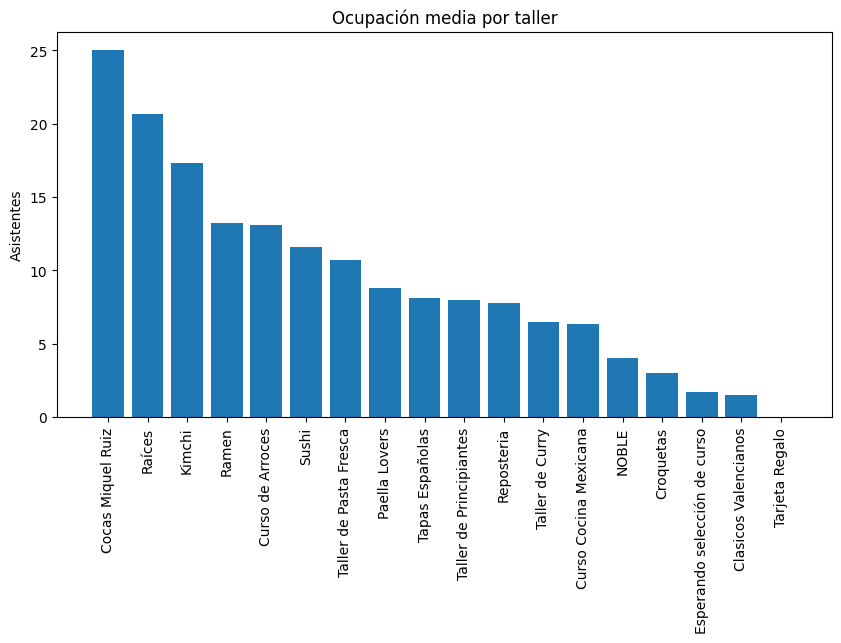

In [14]:
# Visualizar ocupación media

plt.figure(figsize=(10,5))

plt.bar(
    ocupacion_media["Taller"],
    ocupacion_media["Asistentes"]
)

plt.xticks(rotation=90)

plt.title(
    "Ocupación media por taller"
)

plt.ylabel("Asistentes")

plt.show()

# 6. Formulación matemática del problema
## 6.1 Definición del horizonte de planificación

Horizonte de planificación

El modelo de optimización se construirá para un horizonte temporal de 12 semanas, equivalente a un trimestre de actividad.

Se asumirá inicialmente la realización de un único taller por semana, permitiendo seleccionar la combinación de cursos que maximice la asistencia esperada.

In [18]:
# Número de semanas a planificar

num_semanas = 52

semanas = range(1, num_semanas + 1)



## 6.2 Definición de los talleres candidatos

El calendario optimizado se construirá utilizando los principales talleres impartidos de forma recurrente por Food&Fun. Se excluyen aquellos talleres especiales o realizados de manera puntual, con el fin de centrar la planificación en la oferta habitual de la empresa.

In [19]:
# Talleres incluidos en el modelo

talleres = [
    "Curso de Arroces",
    "Paella Lovers",
    "Sushi",
    "Ramen",
    "Kimchi",
    "Taller de Pasta Fresca",
    "Reposteria",
    "Tapas Españolas",
    "Taller de Principiantes"
]

talleres

['Curso de Arroces',
 'Paella Lovers',
 'Sushi',
 'Ramen',
 'Kimchi',
 'Taller de Pasta Fresca',
 'Reposteria',
 'Tapas Españolas',
 'Taller de Principiantes']

## 6.3 Definición de los parámetros

La ocupación esperada de cada taller se aproximará mediante la ocupación media histórica observada durante el periodo analizado.

Estos valores actuarán como parámetro de entrada del modelo de optimización.

In [20]:
ocupacion_media_modelo = ocupacion_media[
    ocupacion_media["Taller"].isin(talleres)
].copy()

ocupacion_media_modelo

,Taller,Asistentes
6,Kimchi,17.333333
9,Ramen,13.250000
4,Curso de Arroces,13.083333
12,Sushi,11.578947
14,Taller de Pasta Fresca,10.714286
8,Paella Lovers,8.821429
16,Tapas Españolas,8.111111
15,Taller de Principiantes,8.000000
11,Reposteria,7.750000


In [21]:
# Diccionario de ocupación esperada

ocupacion = dict(
    zip(
        ocupacion_media_modelo["Taller"],
        ocupacion_media_modelo["Asistentes"]
    )
)

ocupacion

{'Kimchi': 17.333333333333332,
 'Ramen': 13.25,
 'Curso de Arroces': 13.083333333333334,
 'Sushi': 11.578947368421053,
 'Taller de Pasta Fresca': 10.714285714285714,
 'Paella Lovers': 8.821428571428571,
 'Tapas Españolas': 8.11111111111111,
 'Taller de Principiantes': 8.0,
 'Reposteria': 7.75}

## 6.4 Variables de decisión

Se define una variable binaria para cada combinación de taller y semana.

La variable toma valor 1 si el taller se programa en una determinada semana y 0 en caso contrario.

In [22]:
# Creación del modelo

modelo = gp.Model(
    "Calendario_FoodFun"
)

In [23]:
# Variables binarias

x = modelo.addVars(
    talleres,
    semanas,
    vtype=GRB.BINARY,
    name="x"
)

## 6.5 Función objetivo

El objetivo del modelo consiste en maximizar la asistencia total esperada durante el horizonte de planificación.

Para ello se utilizará la ocupación media histórica de cada taller como estimación de la demanda esperada.

In [24]:
modelo.setObjective(

    gp.quicksum(
        ocupacion[t] * x[t, s]
        for t in talleres
        for s in semanas
    ),

    GRB.MAXIMIZE

)

## 6.6 Restricción de capacidad

Se establece que únicamente podrá impartirse un taller por semana.

In [25]:
for s in semanas:

    modelo.addConstr(

        gp.quicksum(
            x[t, s]
            for t in talleres
        ) == 1,

        name=f"Semana_{s}"
    )

## 6.7 Restricciones de negocio
## 6.7.1 No repetir el mismo taller en semanas consecutivas
### Restricción de diversidad de la oferta

Con el fin de evitar la repetición excesiva de un mismo curso y mantener una oferta atractiva para los clientes, no se permitirá programar el mismo taller en semanas consecutivas.

In [26]:
for t in talleres:

    for s in range(1, num_semanas):

        modelo.addConstr(

            x[t, s] + x[t, s + 1] <= 1,

            name=f"NoConsecutivo_{t}_{s}"

        )

## 6.7.2 Frecuencia mínima de talleres estratégicos
### Restricción de frecuencia mínima

Los talleres con mayor relevancia estratégica deberán aparecer de forma periódica a lo largo del año para garantizar una oferta equilibrada.

In [27]:
modelo.addConstr(

    gp.quicksum(
        x["Curso de Arroces", s]
        for s in semanas
    ) >= 12,

    name="Arroces_Minimo"

)

<gurobi.Constr *Awaiting Model Update*>

In [28]:
modelo.addConstr(

    gp.quicksum(
        x["Paella Lovers", s]
        for s in semanas
    ) >= 12,

    name="Paella_Minimo"

)

<gurobi.Constr *Awaiting Model Update*>

## 6.7.3 Restricción estacional
### Restricción estacional

Los talleres de Kimchi y Ramen presentan una demanda asociada a los meses más fríos del año. Por ello, su programación se limitará a los periodos de otoño e invierno.

In [29]:
# Semanas donde se permite Kimchi y Ramen

semanas_frio = list(range(1, 14)) + list(range(40, 53))

semanas_frio

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52]

In [30]:
# Restricción estacional Kimchi

for s in semanas:

    if s not in semanas_frio:

        modelo.addConstr(
            x["Kimchi", s] == 0,
            name=f"Kimchi_{s}"
        )

In [31]:
# Restricción estacional Ramen

for s in semanas:

    if s not in semanas_frio:

        modelo.addConstr(
            x["Ramen", s] == 0,
            name=f"Ramen_{s}"
        )

# 7. Resolución del modelo

Una vez definidas la función objetivo y las restricciones operativas, se procede a resolver el problema de optimización utilizando Gurobi.

In [32]:
modelo.optimize()

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 24.4.0 24E263)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 565 rows, 468 columns and 1542 nonzeros (Max)
Model fingerprint: 0x81cc49ee
Model has 468 linear objective coefficients
Variable types: 0 continuous, 468 integer (468 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [8e+00, 2e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+01]

Found heuristic solution: objective 540.6098580
Presolve removed 106 rows and 52 columns
Presolve time: 0.01s
Presolved: 459 rows, 416 columns, 1330 nonzeros
Variable types: 0 continuous, 416 integer (416 binary)

Root relaxation: objective 6.891861e+02, 401 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    

# 8. Obtención del calendario óptimo

In [33]:
# Extraer calendario óptimo

calendario = []

for s in semanas:

    for t in talleres:

        if x[t, s].X > 0.5:

            calendario.append(
                [s, t]
            )

calendario = pd.DataFrame(
    calendario,
    columns=["Semana", "Taller"]
)

calendario

,Semana,Taller
0,1,Kimchi
1,2,Ramen
2,3,Kimchi
3,4,Ramen
4,5,Kimchi
5,6,Ramen
6,7,Kimchi
7,8,Ramen
8,9,Kimchi
9,10,Ramen


In [34]:
# Número de veces que aparece cada taller

calendario["Taller"].value_counts()

Taller
Kimchi              14
Curso de Arroces    13
Ramen               12
Paella Lovers       12
Sushi                1
Name: count, dtype: int64

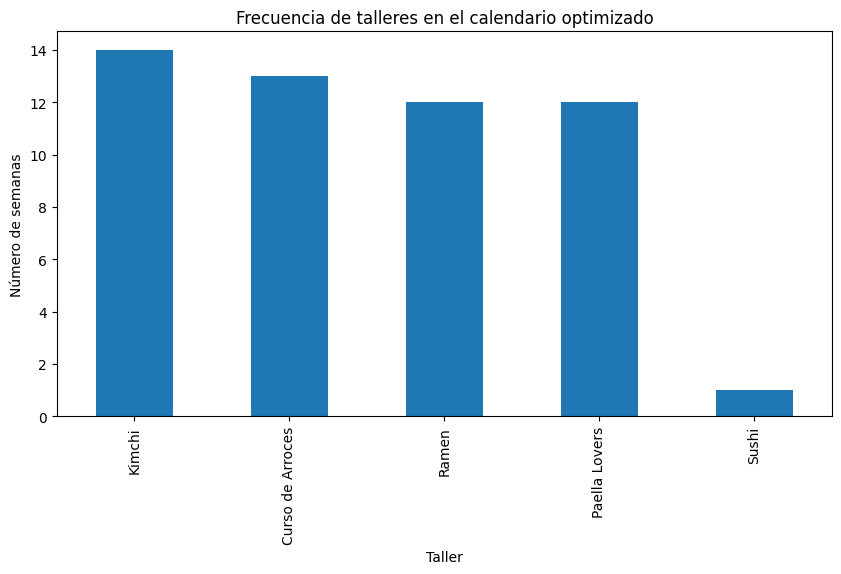

In [35]:
plt.figure(figsize=(10,5))

calendario["Taller"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Frecuencia de talleres en el calendario optimizado"
)

plt.ylabel("Número de semanas")

plt.show()

# 9. Análisis del calendario optimizado

In [36]:
calendario.head(20)

,Semana,Taller
0,1,Kimchi
1,2,Ramen
2,3,Kimchi
3,4,Ramen
4,5,Kimchi
5,6,Ramen
6,7,Kimchi
7,8,Ramen
8,9,Kimchi
9,10,Ramen


In [37]:
calendario["Taller"].value_counts()

Taller
Kimchi              14
Curso de Arroces    13
Ramen               12
Paella Lovers       12
Sushi                1
Name: count, dtype: int64

In [38]:
calendario.to_excel("calendario_optimo.xlsx", index=False)

# 10. Visualización interactiva del calendario optimizado

In [39]:
%pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 12.5 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [40]:
import pandas as pd
import plotly.express as px

# Copia del calendario

calendario_html = calendario.copy()

# Fecha ficticia de inicio del año
fecha_inicio = pd.Timestamp("2026-01-05")

# Convertir semanas en fechas

calendario_html["Inicio"] = (
    fecha_inicio +
    pd.to_timedelta(
        (calendario_html["Semana"] - 1) * 7,
        unit="D"
    )
)

calendario_html["Fin"] = (
    calendario_html["Inicio"] +
    pd.Timedelta(days=6)
)

# Crear calendario interactivo

fig = px.timeline(
    calendario_html,
    x_start="Inicio",
    x_end="Fin",
    y="Taller",
    color="Taller",
    title="Calendario optimizado de talleres Food&Fun"
)

fig.update_yaxes(
    autorange="reversed"
)

fig.show()

### Análisis del calendario inicial obtenido mediante Gurobi

Tras la primera ejecución del modelo de optimización, se observó que Gurobi tendía a seleccionar de forma reiterada aquellos talleres con mayor ocupación histórica esperada. Este comportamiento era coherente con la función objetivo definida inicialmente, cuyo propósito consistía en maximizar el número total de asistentes a lo largo del año.

Sin embargo, el calendario resultante no reflejaba adecuadamente la realidad operativa y comercial de Food&Fun. Aunque cursos como Curso de Arroces, Paella Lovers o Sushi presentan una elevada demanda, la empresa mantiene una oferta formativa más amplia que incluye talleres especializados como Pasta Fresca, Repostería, Taller de Principiantes, Tapas Españolas, Kimchi o Ramen.

La solución inicial obtenida por Gurobi priorizaba exclusivamente la maximización de la ocupación, sin considerar la necesidad de ofrecer variedad en la programación ni la importancia estratégica de determinados cursos dentro del catálogo de la empresa. Como consecuencia, algunos talleres aparecían con una frecuencia muy reducida o incluso quedaban excluidos del calendario anual.

Por este motivo, se decidió reformular el modelo incorporando nuevas restricciones de negocio orientadas a garantizar una programación más equilibrada. Estas restricciones establecen frecuencias mínimas para determinados talleres y consideran aspectos comerciales y estacionales, permitiendo generar un calendario más realista y alineado con la estrategia de Food&Fun.


# 11 Restricción de equilibrio comercial

In [41]:
principales = [
    "Curso de Arroces",
    "Paella Lovers",
    "Sushi",
    "Tapas Españolas"
]

In [42]:
secundarios = [
    "Taller de Pasta Fresca",
    "Reposteria",
    "Taller de Principiantes"
]

In [43]:
estacionales = [
    "Kimchi",
    "Ramen"
]

In [44]:
modelo.addConstr(

    gp.quicksum(
        x["Tapas Españolas", s]
        for s in semanas
    ) >= 12,

    name="Tapas_Minimo"

)

<gurobi.Constr *Awaiting Model Update*>

In [45]:
modelo.addConstr(

    gp.quicksum(
        x["Taller de Pasta Fresca", s]
        for s in semanas
    ) >= 6,

    name="Pasta_Minimo"

)

<gurobi.Constr *Awaiting Model Update*>

In [46]:
modelo.addConstr(

    gp.quicksum(
        x["Reposteria", s]
        for s in semanas
    ) >= 6,

    name="Reposteria_Minimo"

)

<gurobi.Constr *Awaiting Model Update*>

In [47]:
modelo.addConstr(

    gp.quicksum(
        x["Taller de Principiantes", s]
        for s in semanas
    ) >= 6,

    name="Principiantes_Minimo"

)

<gurobi.Constr *Awaiting Model Update*>

Durante la construcción inicial del modelo se asumió que únicamente podía programarse un taller por semana. Sin embargo, tras revisar el funcionamiento real de Food&Fun, se observó que la empresa suele impartir aproximadamente tres talleres semanales, priorizando los días lunes, viernes y sábado.

Esta diferencia implicaba que la formulación inicial no representaba adecuadamente la capacidad operativa de la empresa, limitando artificialmente el número de talleres que podían programarse a lo largo del año.

Por este motivo, se reformuló el modelo de optimización considerando tres sesiones disponibles por semana. De esta forma, el calendario resultante se ajusta mejor a la realidad de la actividad empresarial y permite incorporar una oferta más amplia y equilibrada de talleres.


# 12. Reoptimización del calendario

Una vez incorporadas las restricciones de equilibrio comercial, se procede a resolver nuevamente el modelo de optimización.

El objetivo sigue siendo maximizar la asistencia esperada, pero garantizando simultáneamente una programación más equilibrada y alineada con la estrategia comercial de Food&Fun.

In [48]:
modelo.optimize()

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 24.4.0 24E263)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 569 rows, 468 columns and 1750 nonzeros (Max)
Model fingerprint: 0x46dfaa07
Model has 468 linear objective coefficients
Variable types: 0 continuous, 468 integer (468 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [8e+00, 2e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+01]

MIP start from previous solve did not produce a new incumbent solution
MIP start from previous solve violates constraint Tapas_Minimo by 12.000000000

Presolve removed 106 rows and 52 columns
Presolve time: 0.01s
Presolved: 463 rows, 416 columns, 1538 nonzeros
Variable types: 0 continuous, 416 integer (416 binary)

Root relaxation: infeasible, 534 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |  

In [51]:
print(modelo.Status)

3


Tras analizar los resultados obtenidos en el modelo inicial, se observó que la hipótesis de un único taller semanal no representaba adecuadamente la operativa real de Food&Fun.

La empresa suele impartir aproximadamente tres talleres por semana, priorizando los días lunes, viernes y sábado. Por este motivo, se reformula el modelo considerando tres sesiones semanales disponibles para la programación de actividades.

Esta modificación permite generar un calendario más realista y alineado con la capacidad operativa de la empresa.

## 12.2 Definición del horizonte temporal


In [52]:

# Semanas del año

semanas = range(1, 53)

# Días disponibles para impartir talleres

dias = [
    "Lunes",
    "Viernes",
    "Sabado"
]

len(semanas) * len(dias)

156

In [53]:
# Talleres incluidos

talleres = [
    "Curso de Arroces",
    "Paella Lovers",
    "Sushi",
    "Ramen",
    "Kimchi",
    "Taller de Pasta Fresca",
    "Reposteria",
    "Tapas Españolas",
    "Taller de Principiantes"
]

In [54]:
ocupacion

{'Kimchi': 17.333333333333332,
 'Ramen': 13.25,
 'Curso de Arroces': 13.083333333333334,
 'Sushi': 11.578947368421053,
 'Taller de Pasta Fresca': 10.714285714285714,
 'Paella Lovers': 8.821428571428571,
 'Tapas Españolas': 8.11111111111111,
 'Taller de Principiantes': 8.0,
 'Reposteria': 7.75}

In [55]:
# Crear nuevo modelo

modelo2 = gp.Model(
    "Calendario_Anual_FoodFun"
)

In [56]:
# Variable binaria:
# 1 si el taller se programa
# en una semana y día concreto

x = modelo2.addVars(
    talleres,
    semanas,
    dias,
    vtype=GRB.BINARY,
    name="x"
)

In [57]:
modelo2.setObjective(

    gp.quicksum(

        ocupacion[t] * x[t, s, d]

        for t in talleres
        for s in semanas
        for d in dias

    ),

    GRB.MAXIMIZE

)

In [58]:
# Un único taller por día

for s in semanas:

    for d in dias:

        modelo2.addConstr(

            gp.quicksum(
                x[t, s, d]
                for t in talleres
            ) == 1

        )

## 12.3 Restricciones comerciales

Los talleres con mayor relevancia comercial para Food&Fun deberán aparecer con una frecuencia mínima a lo largo del año para garantizar una oferta estable y alineada con la estrategia de la empresa.

In [59]:
# Curso de Arroces mínimo 12 veces

modelo2.addConstr(

    gp.quicksum(
        x["Curso de Arroces", s, d]
        for s in semanas
        for d in dias
    ) >= 12,

    name="Arroces_Minimo"

)

<gurobi.Constr *Awaiting Model Update*>

In [60]:
# Paella Lovers mínimo 12 veces

modelo2.addConstr(

    gp.quicksum(
        x["Paella Lovers", s, d]
        for s in semanas
        for d in dias
    ) >= 12,

    name="Paella_Minimo"

)

<gurobi.Constr *Awaiting Model Update*>

In [61]:
# Tapas Españolas mínimo 12 veces

modelo2.addConstr(

    gp.quicksum(
        x["Tapas Españolas", s, d]
        for s in semanas
        for d in dias
    ) >= 12,

    name="Tapas_Minimo"

)

<gurobi.Constr *Awaiting Model Update*>

### 12.3.2 Talleres secundarios

In [62]:
# Pasta Fresca mínimo 6 veces

modelo2.addConstr(

    gp.quicksum(
        x["Taller de Pasta Fresca", s, d]
        for s in semanas
        for d in dias
    ) >= 6,

    name="Pasta_Minimo"

)

<gurobi.Constr *Awaiting Model Update*>

In [63]:
# Repostería mínimo 6 veces

modelo2.addConstr(

    gp.quicksum(
        x["Reposteria", s, d]
        for s in semanas
        for d in dias
    ) >= 6,

    name="Reposteria_Minimo"

)

<gurobi.Constr *Awaiting Model Update*>

In [64]:
# Principiantes mínimo 6 veces

modelo2.addConstr(

    gp.quicksum(
        x["Taller de Principiantes", s, d]
        for s in semanas
        for d in dias
    ) >= 6,

    name="Principiantes_Minimo"

)

<gurobi.Constr *Awaiting Model Update*>

### 12.3.3 Restricción estacional

In [65]:
# Semanas frías

semanas_frio = list(range(1,14)) + list(range(40,53))

In [66]:
for s in semanas:

    if s not in semanas_frio:

        for d in dias:

            modelo2.addConstr(
                x["Kimchi", s, d] == 0
            )

In [67]:
for s in semanas:

    if s not in semanas_frio:

        for d in dias:

            modelo2.addConstr(
                x["Ramen", s, d] == 0
            )

In [68]:
#Diversificación semanal: un taller no puede repetirse en la misma semana
for s in semanas:

    for t in talleres:

        modelo2.addConstr(

            gp.quicksum(
                x[t, s, d]
                for d in dias
            ) <= 1

        )

In [69]:
modelo2.optimize()

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 24.4.0 24E263)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 786 rows, 1404 columns and 3900 nonzeros (Max)
Model fingerprint: 0x9a248a43
Model has 1404 linear objective coefficients
Variable types: 0 continuous, 1404 integer (1404 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [8e+00, 2e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+01]

Found heuristic solution: objective 1618.2955305
Presolve removed 208 rows and 156 columns
Presolve time: 0.02s
Presolved: 578 rows, 1248 columns, 3432 nonzeros
Variable types: 0 continuous, 1248 integer (1248 binary)

Root relaxation: objective 1.953266e+03, 999 iterations, 0.01 seconds (0.01 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Ti

In [70]:
print(modelo2.Status)

2


# 13. Obtención del calendario optimizado

In [71]:
# Extraer calendario optimizado

calendario_final = []

for s in semanas:

    for d in dias:

        for t in talleres:

            if x[t, s, d].X > 0.5:

                calendario_final.append(
                    [s, d, t]
                )

calendario_final = pd.DataFrame(
    calendario_final,
    columns=[
        "Semana",
        "Dia",
        "Taller"
    ]
)

calendario_final.head(20)

,Semana,Dia,Taller
0,1,Lunes,Ramen
1,1,Viernes,Kimchi
2,1,Sabado,Curso de Arroces
3,2,Lunes,Curso de Arroces
4,2,Viernes,Kimchi
5,2,Sabado,Ramen
6,3,Lunes,Curso de Arroces
7,3,Viernes,Kimchi
8,3,Sabado,Ramen
9,4,Lunes,Curso de Arroces


In [72]:
calendario_final.shape

(156, 3)

In [73]:
calendario_final["Taller"].value_counts()

Taller
Curso de Arroces           52
Ramen                      26
Kimchi                     26
Tapas Españolas            12
Paella Lovers              12
Sushi                      10
Reposteria                  6
Taller de Pasta Fresca      6
Taller de Principiantes     6
Name: count, dtype: int64

In [74]:
calendario_final.to_excel(
    "Calendario_Optimizado_FoodFun_2026.xlsx",
    index=False
)



Una vez resuelto el modelo de optimización, se obtuvo un calendario anual compuesto por 156 sesiones distribuidas entre los días lunes, viernes y sábado. La solución encontrada por Gurobi garantiza el cumplimiento de todas las restricciones operativas, comerciales y estacionales definidas previamente, maximizando simultáneamente la asistencia esperada.

El calendario resultante constituye una propuesta de planificación anual basada en criterios cuantitativos, proporcionando una herramienta de apoyo a la toma de decisiones para la programación de talleres en Food&Fun.


In [ ]:
st.sidebar.title("Food&Fun")

opcion = st.sidebar.radio(
    "Seleccionar módulo",
    [
        "Dashboard",
        "Predicción de Demanda",
        "Predicción de Ocupación",
        "Calendario Optimizado",
        "Conclusiones"
    ]
)